<a href="https://colab.research.google.com/github/reyhanfisena/rainfall-forecasting-pasuruan/blob/main/analisis_korelasi_curah_hujan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Analisis Korelasi Variabel Meteorologi BMKG
## Terhadap Curah Hujan (RR)

**Tujuan:** Menentukan variabel meteorologi mana yang paling berkorelasi dengan curah hujan, diurutkan berdasarkan tingkat kepentingannya.

**Metode yang digunakan:**
| # | Metode | Keunggulan |
|---|--------|------------|
| 1 | Korelasi Pearson & Spearman | Hubungan linear & monoton |
| 2 | Mutual Information | Hubungan non-linear |
| 3 | Random Forest Feature Importance | Interaksi antar fitur |

---
**Deskripsi Kolom BMKG:**
- `TN` → Suhu Minimum (°C)
- `TX` → Suhu Maksimum (°C)
- `TAVG` → Suhu Rata-rata (°C)
- `RH_AVG` → Kelembapan Udara Rata-rata (%)
- `RR` → **Curah Hujan (mm) ← TARGET**
- `SS` → Lama Penyinaran Matahari (jam)
- `FF_X` → Kecepatan Angin Maksimum (m/s)
- `DDD_X` → Arah Angin saat Kecepatan Maks (°)
- `FF_AVG` → Kecepatan Angin Rata-rata (m/s)

## 📦 Langkah 1 — Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


## Load & Eksplorasi Data


In [ ]:
# ── Ganti nama file jika berbeda ──
FILE_CSV = "all_var.csv"

df = pd.read_csv(FILE_CSV)

print(f'Jumlah baris  : {len(df)}')
print(f'Jumlah kolom  : {len(df.columns)}')
print(f'Kolom         : {list(df.columns)}')
print(f'\nMissing values:')
print(df.isnull().sum())

Jumlah baris  : 365
Jumlah kolom  : 10
Kolom         : ['TANGGAL', 'TN', 'TX', 'TAVG', 'RH_AVG', 'RR', 'SS', 'FF_X', 'DDD_X', 'FF_AVG']

Missing values:
TANGGAL    0
TN         1
TX         0
TAVG       0
RH_AVG     0
RR         0
SS         0
FF_X       0
DDD_X      0
FF_AVG     0
dtype: int64


In [ ]:
# Tampilkan 5 baris pertama
df.head()

,TANGGAL,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,FF_AVG
0,01-01-2025,19.4,24.8,21.7,94.0,36.1,2.0,0,0,0
1,02-01-2025,18.8,24.5,20.6,96.0,33.5,0.0,2,45,0
2,03-01-2025,19.0,25.8,22.4,90.0,34.8,0.8,2,130,0
3,04-01-2025,18.6,23.4,20.8,96.0,0.0,0.8,0,0,0
4,05-01-2025,19.2,24.4,20.8,95.9,45.0,0.6,2,10,0


In [ ]:
# Statistik deskriptif
df.describe().round(2)

,TN,TX,TAVG,RH_AVG,RR,SS,FF_X,DDD_X,FF_AVG
count,364.00,365.00,365.00,365.00,365.00,365.00,365.00,365.00,365.00
mean,18.01,26.31,21.86,88.91,11.88,3.02,1.84,54.67,0.31
std,1.23,1.42,0.87,4.91,18.73,2.34,1.32,62.78,0.52
min,13.00,22.40,18.80,72.72,0.00,0.00,0.00,0.00,0.00
25%,17.40,25.20,21.30,84.98,0.00,1.20,1.00,10.00,0.00
50%,18.20,26.30,21.90,89.78,1.60,2.30,2.00,40.00,0.00
75%,18.80,27.40,22.40,93.00,17.40,4.50,3.00,80.00,1.00
max,21.00,30.20,24.80,98.20,109.00,8.00,8.00,250.00,3.00


##  Preprocessing

In [ ]:
DESKRIPSI_KOLOM = {
    "TN":     "Suhu Minimum (°C)",
    "TX":     "Suhu Maksimum (°C)",
    "TAVG":   "Suhu Rata-rata (°C)",
    "RH_AVG": "Kelembapan Udara Rata-rata (%)",
    "RR":     "Curah Hujan (mm) ← TARGET",
    "SS":     "Lama Penyinaran Matahari (jam)",
    "FF_X":   "Kecepatan Angin Maksimum (m/s)",
    "DDD_X":  "Arah Angin saat Kec. Maks (°)",
    "FF_AVG": "Kecepatan Angin Rata-rata (m/s)",
}

# Drop kolom tanggal & baris dengan missing value
df_clean = df.drop(columns=["TANGGAL"], errors="ignore")
df_clean = df_clean.dropna()

TARGET = "RR"
FITUR  = [c for c in df_clean.columns if c != TARGET]

X = df_clean[FITUR]
y = df_clean[TARGET]

print(f'Data setelah cleaning : {len(df_clean)} baris')
print(f'Fitur (X)             : {FITUR}')
print(f'Target (y)            : {TARGET} — Curah Hujan (mm)')

Data setelah cleaning : 364 baris
Fitur (X)             : ['TN', 'TX', 'TAVG', 'RH_AVG', 'SS', 'FF_X', 'DDD_X', 'FF_AVG']
Target (y)            : RR — Curah Hujan (mm)


## 📊 Langkah 4 — Distribusi Curah Hujan (Target)

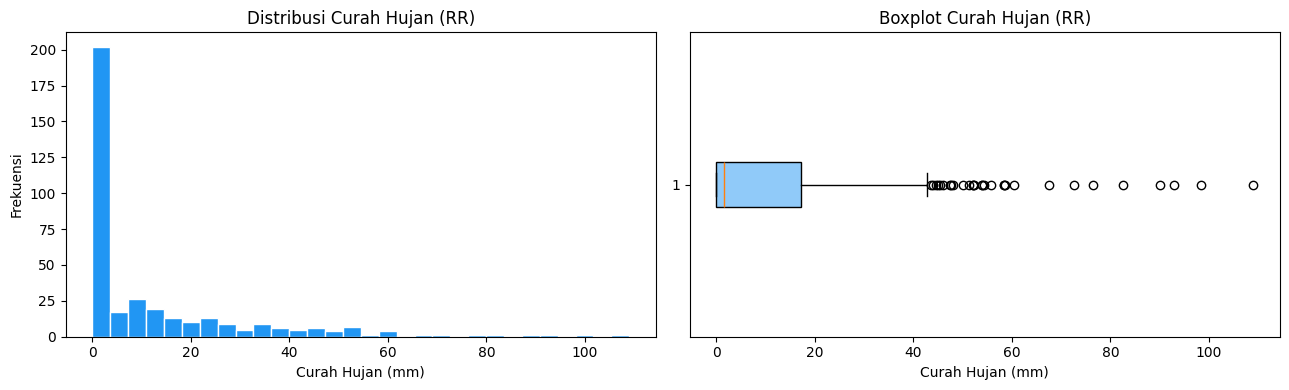

Mean   : 11.86 mm
Median : 1.60 mm
Max    : 109.00 mm
Hari tanpa hujan (RR=0): 144 hari (39.6%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y, bins=30, color='#2196F3', edgecolor='white')
axes[0].set_title('Distribusi Curah Hujan (RR)', fontsize=12)
axes[0].set_xlabel('Curah Hujan (mm)')
axes[0].set_ylabel('Frekuensi')

axes[1].boxplot(y, vert=False, patch_artist=True,
                boxprops=dict(facecolor='#90CAF9'))
axes[1].set_title('Boxplot Curah Hujan (RR)', fontsize=12)
axes[1].set_xlabel('Curah Hujan (mm)')

plt.tight_layout()
plt.show()

print(f'Mean   : {y.mean():.2f} mm')
print(f'Median : {y.median():.2f} mm')
print(f'Max    : {y.max():.2f} mm')
print(f'Hari tanpa hujan (RR=0): {(y == 0).sum()} hari ({(y==0).mean()*100:.1f}%)')

---
##  Korelasi Pearson & Spearman

- **Pearson** → mengukur hubungan **linear** antara dua variabel
- **Spearman** → mengukur hubungan **monoton** (tidak harus linear), lebih robust terhadap outlier
- Nilai mendekati **+1** = korelasi positif kuat, **−1** = negatif kuat, **0** = tidak ada korelasi

In [ ]:
pearson_corr  = X.apply(lambda col: col.corr(y, method='pearson'))
spearman_corr = X.apply(lambda col: col.corr(y, method='spearman'))

df_corr = pd.DataFrame({
    'Pearson':  pearson_corr,
    'Spearman': spearman_corr,
}).sort_values('Spearman', key=abs, ascending=False)

df_corr['Keterangan'] = [DESKRIPSI_KOLOM.get(i, i) for i in df_corr.index]
df_corr.style.background_gradient(cmap='RdYlGn', subset=['Pearson', 'Spearman']).format({'Pearson': '{:.3f}', 'Spearman': '{:.3f}'})

,Pearson,Spearman,Keterangan
RH_AVG,0.525,0.788,Kelembapan Udara Rata-rata (%)
SS,-0.327,-0.450,Lama Penyinaran Matahari (jam)
TX,-0.287,-0.379,Suhu Maksimum (°C)
TN,0.256,0.324,Suhu Minimum (°C)
FF_AVG,-0.151,-0.239,Kecepatan Angin Rata-rata (m/s)
FF_X,-0.169,-0.230,Kecepatan Angin Maksimum (m/s)
TAVG,-0.147,-0.158,Suhu Rata-rata (°C)
DDD_X,-0.090,-0.156,Arah Angin saat Kec. Maks (°)


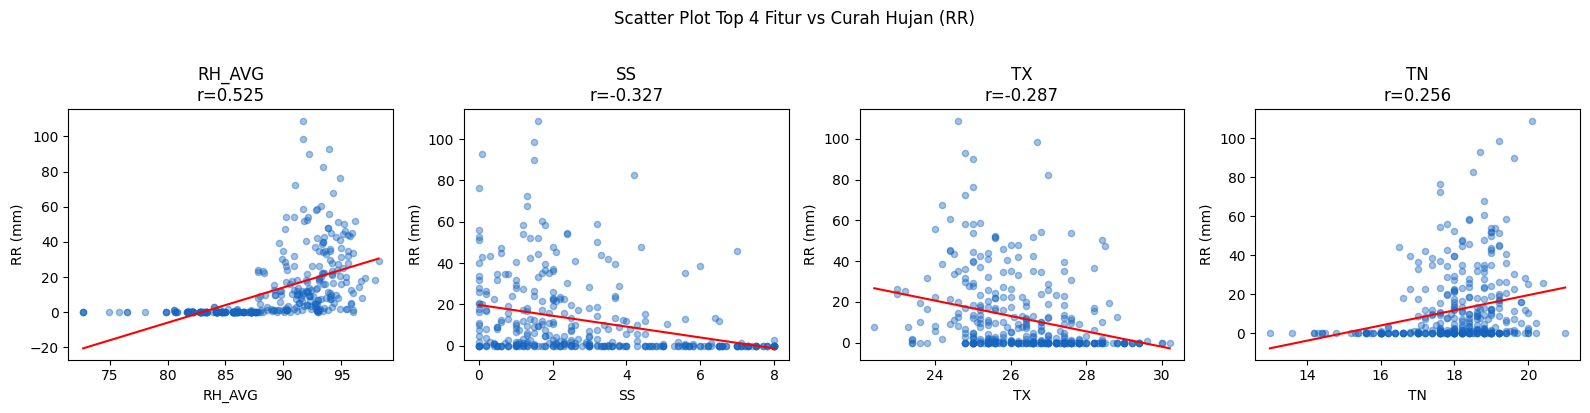

In [ ]:
# Scatter plot top 4 fitur vs RR
top4 = df_corr.index[:4].tolist()
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, top4):
    ax.scatter(df_clean[col], y, alpha=0.4, s=20, color='#1565C0')
    m, b = np.polyfit(df_clean[col], y, 1)
    xline = np.linspace(df_clean[col].min(), df_clean[col].max(), 100)
    ax.plot(xline, m*xline + b, color='red', linewidth=1.5)
    ax.set_xlabel(col)
    ax.set_ylabel('RR (mm)')
    r = pearson_corr[col]
    ax.set_title(f'{col}\nr={r:.3f}')

plt.suptitle('Scatter Plot Top 4 Fitur vs Curah Hujan (RR)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
##  Mutual Information (MI)

- Mengukur **seberapa banyak informasi** dari fitur X yang dapat menjelaskan variabel target Y
- Mampu menangkap hubungan **non-linear** (keunggulan dibanding Pearson)
- Nilai **0** = tidak ada informasi bersama, nilai besar = hubungan kuat

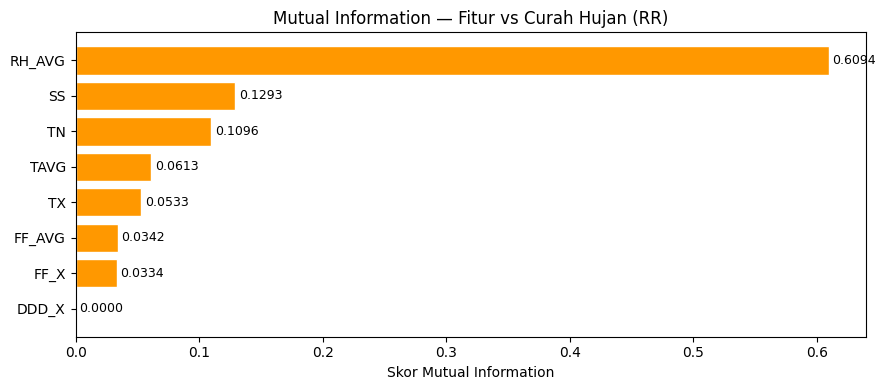

,Mutual Information,Keterangan
RH_AVG,0.609401,Kelembapan Udara Rata-rata (%)
SS,0.129341,Lama Penyinaran Matahari (jam)
TN,0.109647,Suhu Minimum (°C)
TAVG,0.061254,Suhu Rata-rata (°C)
TX,0.053284,Suhu Maksimum (°C)
FF_AVG,0.034192,Kecepatan Angin Rata-rata (m/s)
FF_X,0.033435,Kecepatan Angin Maksimum (m/s)
DDD_X,0.000000,Arah Angin saat Kec. Maks (°)


In [ ]:
mi_scores = mutual_info_regression(X, y, random_state=42)

df_mi = pd.DataFrame({
    'Mutual Information': mi_scores
}, index=FITUR).sort_values('Mutual Information', ascending=False)

df_mi['Keterangan'] = [DESKRIPSI_KOLOM.get(i, i) for i in df_mi.index]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(df_mi.index, df_mi['Mutual Information'],
               color='#FF9800', edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Skor Mutual Information')
ax.set_title('Mutual Information — Fitur vs Curah Hujan (RR)', fontsize=12)
for bar, val in zip(bars, df_mi['Mutual Information']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

df_mi.style.bar(subset=['Mutual Information'], color='#FFB74D')

---
## Random Forest Feature Importance

- **Impurity-based**: Seberapa sering fitur dipakai untuk memisahkan data di dalam pohon keputusan
- **Permutation Importance** *(lebih andal)*: Mengukur penurunan performa model ketika nilai fitur diacak
- Mampu menangkap **interaksi antar fitur**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

r2_train = rf.score(X_train, y_train)
r2_test  = rf.score(X_test,  y_test)

print(f'R² Training : {r2_train:.3f}')
print(f'R² Testing  : {r2_test:.3f}')

R² Training : 0.905
R² Testing  : 0.425


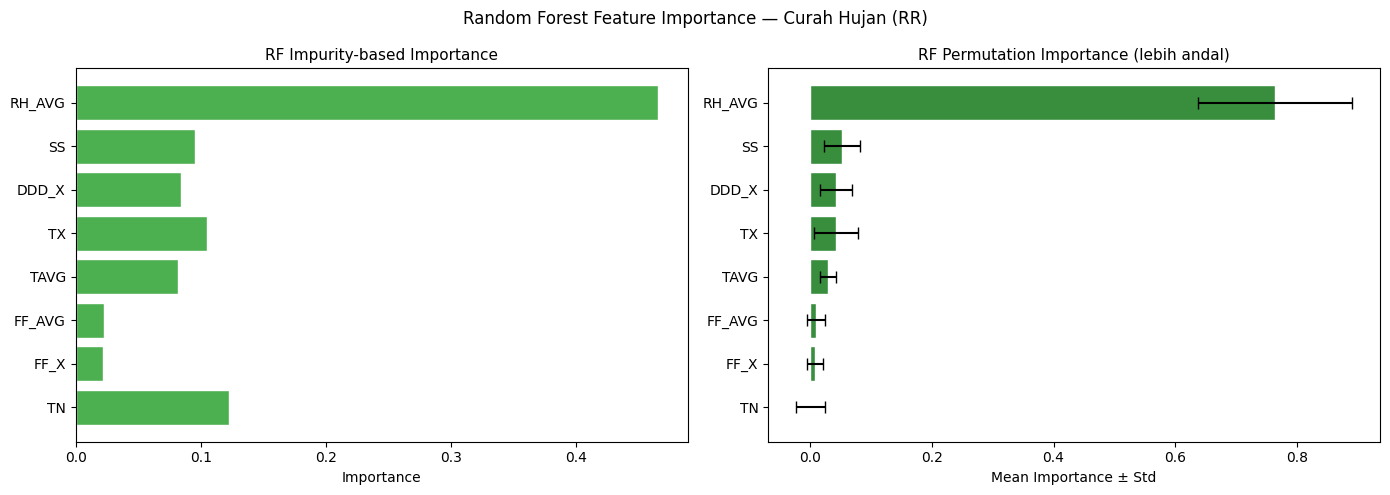

,RF Impurity,RF Permutation,Keterangan
RH_AVG,0.4661,0.7639,Kelembapan Udara Rata-rata (%)
SS,0.0951,0.0525,Lama Penyinaran Matahari (jam)
DDD_X,0.0847,0.0432,Arah Angin saat Kec. Maks (°)
TX,0.1053,0.0427,Suhu Maksimum (°C)
TAVG,0.0817,0.0294,Suhu Rata-rata (°C)
FF_AVG,0.0227,0.0101,Kecepatan Angin Rata-rata (m/s)
FF_X,0.0216,0.0082,Kecepatan Angin Maksimum (m/s)
TN,0.1228,0.0013,Suhu Minimum (°C)


In [ ]:
# Permutation importance (lebih andal)
perm = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42)
perm_importance = pd.Series(perm.importances_mean, index=FITUR)
perm_std        = pd.Series(perm.importances_std,  index=FITUR)

rf_importance = pd.Series(rf.feature_importances_, index=FITUR)

df_rf = pd.DataFrame({
    'RF Impurity':     rf_importance,
    'RF Permutation':  perm_importance,
    'Perm Std':        perm_std,
}).sort_values('RF Permutation', ascending=False)

df_rf['Keterangan'] = [DESKRIPSI_KOLOM.get(i, i) for i in df_rf.index]

# Plot dengan error bar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(df_rf.index, df_rf['RF Impurity'], color='#4CAF50', edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_title('RF Impurity-based Importance', fontsize=11)
axes[0].set_xlabel('Importance')

axes[1].barh(df_rf.index, df_rf['RF Permutation'],
             xerr=df_rf['Perm Std'],
             color='#388E3C', edgecolor='white',
             error_kw=dict(elinewidth=1.5, capsize=4, color='#1B5E20'))
axes[1].invert_yaxis()
axes[1].set_title('RF Permutation Importance (lebih andal)', fontsize=11)
axes[1].set_xlabel('Mean Importance ± Std')

plt.suptitle('Random Forest Feature Importance — Curah Hujan (RR)', fontsize=12)
plt.tight_layout()
plt.show()

df_rf[['RF Impurity', 'RF Permutation', 'Keterangan']].style.background_gradient(
    cmap='Greens', subset=['RF Impurity', 'RF Permutation']
).format({'RF Impurity': '{:.4f}', 'RF Permutation': '{:.4f}'})

---
## Rekap Ranking Gabungan — 3 Metode

Setiap skor dinormalisasi ke rentang **0–1** kemudian dirata-ratakan untuk menghasilkan **Skor Gabungan**.

In [ ]:
def normalize(s):
    s = s.copy().abs()
    if s.max() == 0:
        return s
    return (s - s.min()) / (s.max() - s.min())

df_rekap = pd.DataFrame(index=FITUR)
df_rekap['Pearson_norm']  = normalize(pearson_corr)
df_rekap['Spearman_norm'] = normalize(spearman_corr)
df_rekap['MI_norm']       = normalize(pd.Series(mi_scores, index=FITUR))
df_rekap['RF_norm']       = normalize(perm_importance)
df_rekap['SKOR_GABUNGAN'] = df_rekap.mean(axis=1)
df_rekap = df_rekap.sort_values('SKOR_GABUNGAN', ascending=False)
df_rekap['RANK'] = range(1, len(df_rekap) + 1)
df_rekap['Keterangan'] = [DESKRIPSI_KOLOM.get(i, i) for i in df_rekap.index]

df_rekap[['RANK', 'Pearson_norm', 'Spearman_norm', 'MI_norm', 'RF_norm',
           'SKOR_GABUNGAN', 'Keterangan']].style\
    .background_gradient(cmap='YlOrRd', subset=['SKOR_GABUNGAN'])\
    .background_gradient(cmap='Blues', subset=['Pearson_norm', 'Spearman_norm', 'MI_norm', 'RF_norm'])\
    .format({c: '{:.3f}' for c in ['Pearson_norm', 'Spearman_norm', 'MI_norm', 'RF_norm', 'SKOR_GABUNGAN']})

,RANK,Pearson_norm,Spearman_norm,MI_norm,RF_norm,SKOR_GABUNGAN,Keterangan
RH_AVG,1,1.000,1.000,1.000,1.000,1.000,Kelembapan Udara Rata-rata (%)
SS,2,0.546,0.465,0.212,0.067,0.323,Lama Penyinaran Matahari (jam)
TX,3,0.454,0.353,0.087,0.054,0.237,Suhu Maksimum (°C)
TN,4,0.381,0.265,0.180,0.000,0.207,Suhu Minimum (°C)
FF_X,5,0.181,0.117,0.055,0.009,0.090,Kecepatan Angin Maksimum (m/s)
FF_AVG,6,0.140,0.131,0.056,0.012,0.085,Kecepatan Angin Rata-rata (m/s)
TAVG,7,0.130,0.004,0.101,0.037,0.068,Suhu Rata-rata (°C)
DDD_X,8,0.000,0.000,0.000,0.055,0.014,Arah Angin saat Kec. Maks (°)


---
## Visualisasi Lengkap — 4 Panel

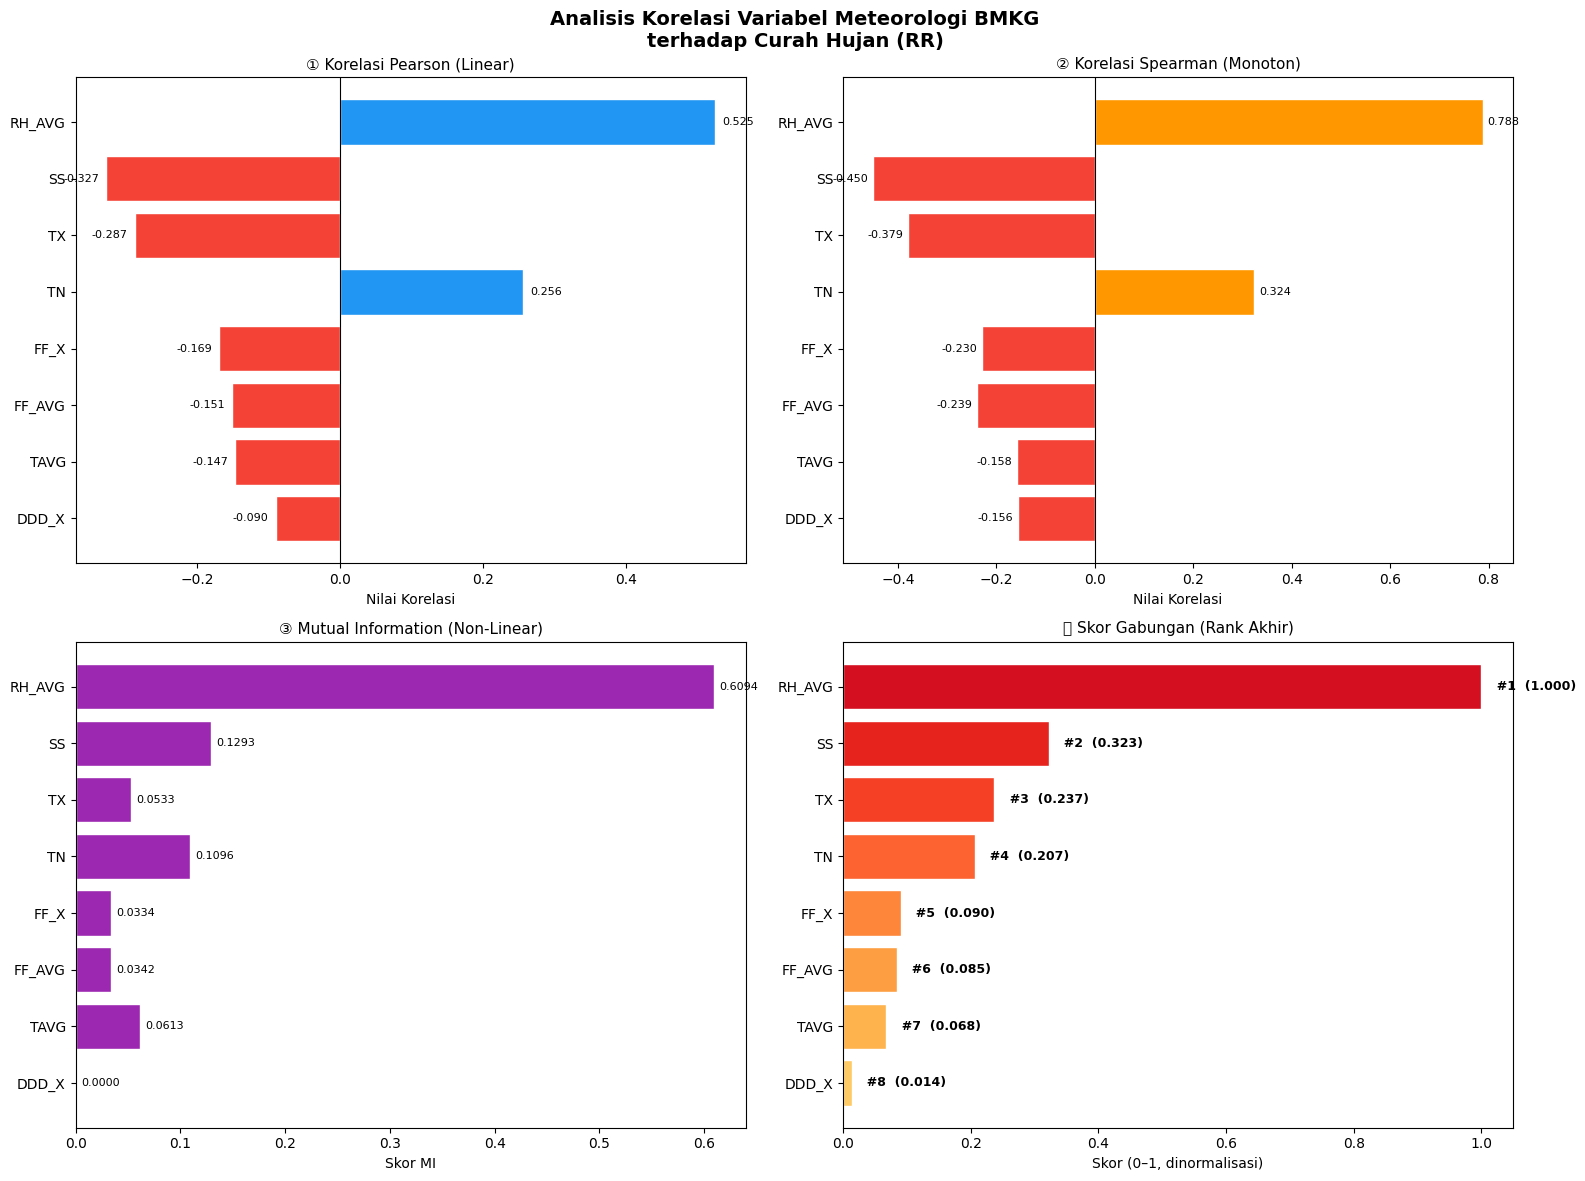

✅ Grafik disimpan: analisis_korelasi_bmkg.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Korelasi Variabel Meteorologi BMKG\nterhadap Curah Hujan (RR)',
             fontsize=14, fontweight='bold')

order = df_rekap.index.tolist()

# Plot 1 — Pearson
vals_p = pearson_corr.reindex(order)
colors_p = ['#F44336' if v < 0 else '#2196F3' for v in vals_p]
axes[0,0].barh(order, vals_p, color=colors_p, edgecolor='white')
axes[0,0].axvline(0, color='black', linewidth=0.8)
axes[0,0].set_title('① Korelasi Pearson (Linear)', fontsize=11)
axes[0,0].set_xlabel('Nilai Korelasi')
axes[0,0].invert_yaxis()
for i, v in enumerate(vals_p):
    axes[0,0].text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.3f}',
                   va='center', ha='left' if v >= 0 else 'right', fontsize=8)

# Plot 2 — Spearman
vals_s = spearman_corr.reindex(order)
colors_s = ['#F44336' if v < 0 else '#FF9800' for v in vals_s]
axes[0,1].barh(order, vals_s, color=colors_s, edgecolor='white')
axes[0,1].axvline(0, color='black', linewidth=0.8)
axes[0,1].set_title('② Korelasi Spearman (Monoton)', fontsize=11)
axes[0,1].set_xlabel('Nilai Korelasi')
axes[0,1].invert_yaxis()
for i, v in enumerate(vals_s):
    axes[0,1].text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.3f}',
                   va='center', ha='left' if v >= 0 else 'right', fontsize=8)

# Plot 3 — Mutual Information
vals_mi = pd.Series(mi_scores, index=FITUR).reindex(order)
axes[1,0].barh(order, vals_mi, color='#9C27B0', edgecolor='white')
axes[1,0].set_title('③ Mutual Information (Non-Linear)', fontsize=11)
axes[1,0].set_xlabel('Skor MI')
axes[1,0].invert_yaxis()
for i, v in enumerate(vals_mi):
    axes[1,0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=8)

# Plot 4 — Skor Gabungan
palette = plt.cm.YlOrRd(np.linspace(0.8, 0.3, len(order)))
bars = axes[1,1].barh(order, df_rekap['SKOR_GABUNGAN'], color=palette, edgecolor='white')
axes[1,1].set_title('🏆 Skor Gabungan (Rank Akhir)', fontsize=11)
axes[1,1].set_xlabel('Skor (0–1, dinormalisasi)')
axes[1,1].invert_yaxis()
for i, (bar, rank) in enumerate(zip(bars, df_rekap['RANK'])):
    w = bar.get_width()
    axes[1,1].text(w + 0.01, i, f'  #{rank}  ({w:.3f})', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('analisis_korelasi_bmkg.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik disimpan: analisis_korelasi_bmkg.png')

---
## Heatmap Korelasi Antar Semua Variabel

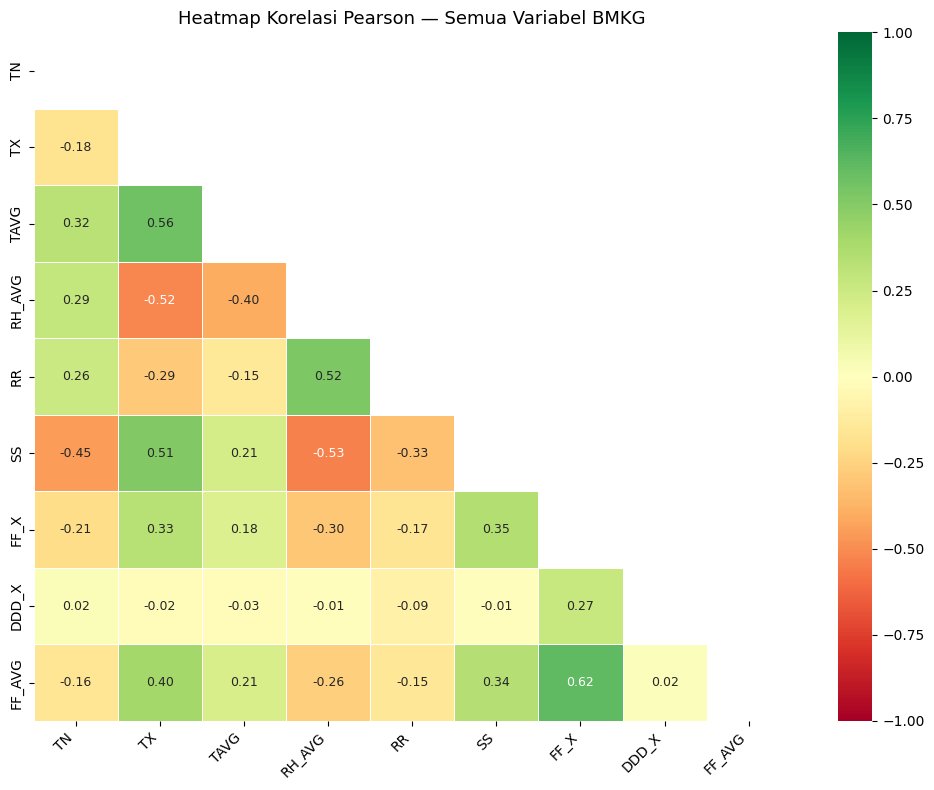

✅ Heatmap disimpan: heatmap_korelasi_bmkg.png


In [ ]:
plt.figure(figsize=(10, 8))
corr_matrix = df_clean.corr(method='pearson')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 9},
    vmin=-1, vmax=1
)
plt.title('Heatmap Korelasi Pearson — Semua Variabel BMKG', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('heatmap_korelasi_bmkg.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap disimpan: heatmap_korelasi_bmkg.png')

---
##  Kesimpulan

In [ ]:
medal = ['1', '2', '3', '4️', '5️', '6️', '7️', '8️']

print('=' * 60)
print('  RANKING VARIABEL METEOROLOGI → CURAH HUJAN (RR)')
print('=' * 60)
for i, (var, row) in enumerate(df_rekap.iterrows()):
    desc = DESKRIPSI_KOLOM.get(var, var).replace(' ← TARGET', '')
    print(f"{medal[i]}  {var:<8} {desc:<35} Skor: {row['SKOR_GABUNGAN']:.3f}")

print()
print('💡 Interpretasi:')
top_var = df_rekap.index[0]
top_p   = pearson_corr[top_var]
top_sp  = spearman_corr[top_var]
print(f'   • {top_var} adalah prediktor TERKUAT dengan Pearson={top_p:.3f}, Spearman={top_sp:.3f}')
bottom_var = df_rekap.index[-1]
print(f'   • {bottom_var} adalah prediktor TERLEMAH — pertimbangkan untuk di-drop saat modeling')
print(f'   • R² Random Forest (test): {r2_test:.3f} menggunakan semua fitur')
print()
print('📌 Rekomendasi fitur untuk model prediksi curah hujan:')
top3 = df_rekap.index[:3].tolist()
print(f'   Minimal gunakan: {top3}')

  RANKING VARIABEL METEOROLOGI → CURAH HUJAN (RR)
1  RH_AVG   Kelembapan Udara Rata-rata (%)      Skor: 1.000
2  SS       Lama Penyinaran Matahari (jam)      Skor: 0.323
3  TX       Suhu Maksimum (°C)                  Skor: 0.237
4️  TN       Suhu Minimum (°C)                   Skor: 0.207
5️  FF_X     Kecepatan Angin Maksimum (m/s)      Skor: 0.090
6️  FF_AVG   Kecepatan Angin Rata-rata (m/s)     Skor: 0.085
7️  TAVG     Suhu Rata-rata (°C)                 Skor: 0.068
8️  DDD_X    Arah Angin saat Kec. Maks (°)       Skor: 0.014

💡 Interpretasi:
   • RH_AVG adalah prediktor TERKUAT dengan Pearson=0.525, Spearman=0.788
   • DDD_X adalah prediktor TERLEMAH — pertimbangkan untuk di-drop saat modeling
   • R² Random Forest (test): 0.425 menggunakan semua fitur

📌 Rekomendasi fitur untuk model prediksi curah hujan:
   Minimal gunakan: ['RH_AVG', 'SS', 'TX']
